In [2]:
import pandas as pd

df=pd.read_csv("/workspaces/XYLOFI_AI/week-2/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [5]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [6]:
target = 'Attrition'
print("Target Column:", target)

Target Column: Attrition


In [7]:
attrition_count = df['Attrition'].value_counts()

print(attrition_count)

attrition_rate = (attrition_count['Yes'] / len(df)) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.12%


In [8]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


/tmp/ipykernel_7693/3033750251.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


The dataset is imbalanced because the number of employees who stayed in the company is significantly higher than the number of employees who left. This imbalance should be considered while building machine learning models.

In [9]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
drop_cols = ['EmployeeNumber', 'Over18',
             'StandardHours', 'EmployeeCount']

df.drop(columns=drop_cols, inplace=True)

print(df.shape)

(1470, 31)


In [11]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1470, 44)


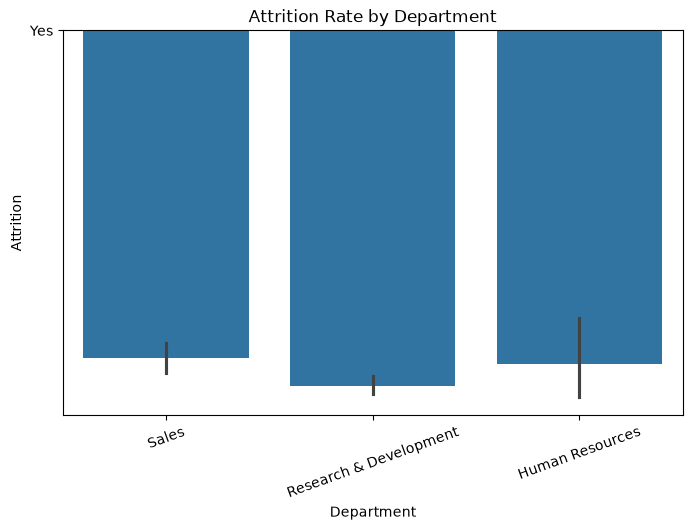

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x='Department',
    y='Attrition',
    data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
)

plt.xticks(rotation=20)
plt.title("Attrition Rate by Department")
plt.savefig('/workspaces/XYLOFI_AI/week-2/charts/attrition_department.png')
plt.show()

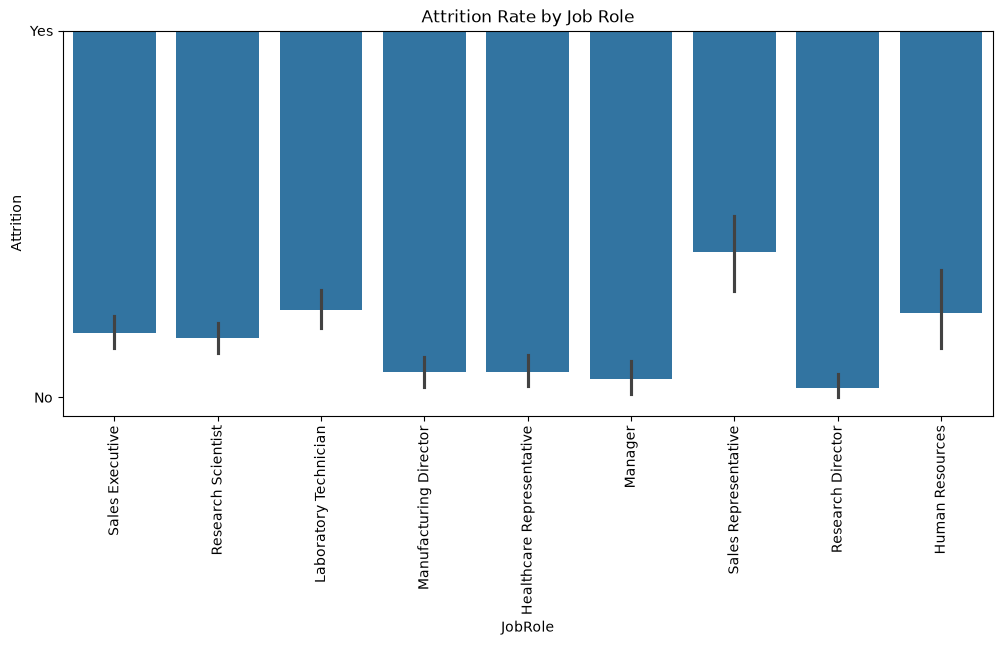

In [21]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='JobRole',
    y='Attrition',
    data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
)

plt.xticks(rotation=90)
plt.title("Attrition Rate by Job Role")
plt.savefig('charts/attrition_jobrole.png')
plt.show()

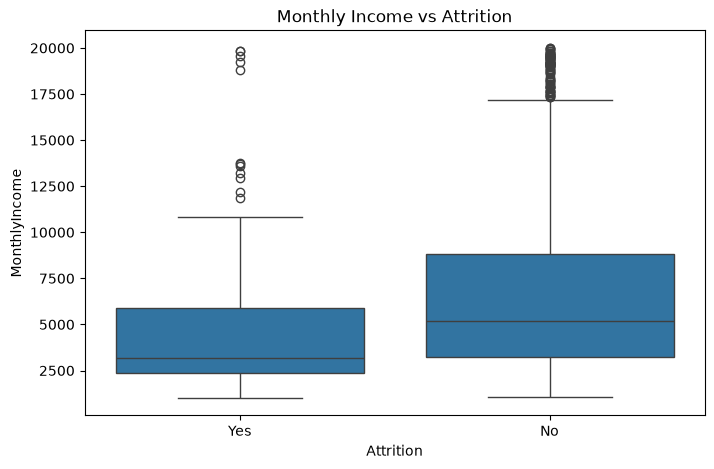

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
)

plt.title("Monthly Income vs Attrition")
plt.savefig('charts/income_attrition.png')
plt.show()

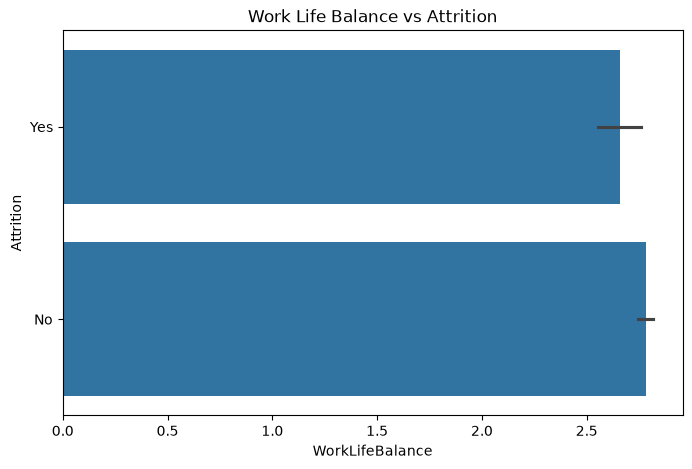

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='WorkLifeBalance',
    y='Attrition',
    data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
)

plt.title("Work Life Balance vs Attrition")
plt.savefig('charts/worklife_attrition.png')
plt.show()

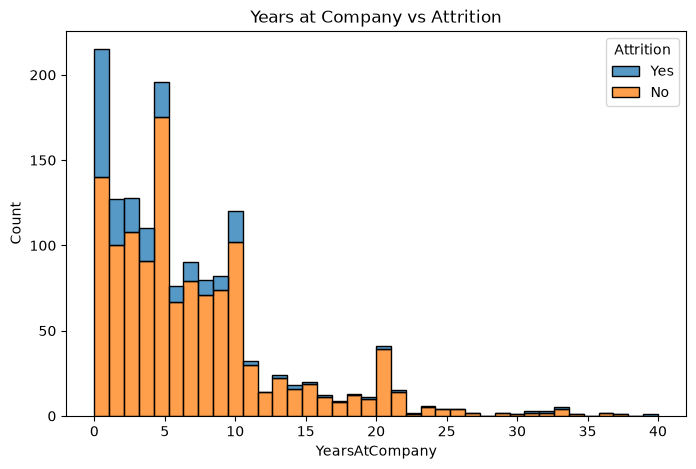

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv'),
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack'
)

plt.title("Years at Company vs Attrition")
plt.savefig('charts/years_attrition.png')
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced')

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
prob_lr = lr.predict_proba(X_test)[:,1]

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:,1]

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:,1]

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

models = {
    "Logistic Regression": (pred_lr, prob_lr),
    "Random Forest": (pred_rf, prob_rf),
    "Gradient Boosting": (pred_gb, prob_gb)
}

results = []

for name, (pred, prob) in models.items():
    print(f"\n{name}")
    print(classification_report(y_test, pred))

    auc = roc_auc_score(y_test, prob)

    results.append({
        "Model": name,
        "ROC-AUC": auc
    })

    print("ROC-AUC Score:", auc)


Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC-AUC Score: 0.798604530967353

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

ROC-AUC Score: 0.7711689206650013

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   mac

In [30]:
comparison = pd.DataFrame(results)
comparison

,Model,ROC-AUC
0,Logistic Regression,0.798605
1,Random Forest,0.771169
2,Gradient Boosting,0.794125


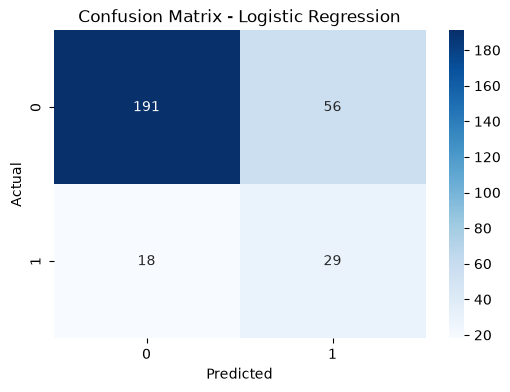

In [32]:
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/confusion_matrix.png")
plt.show()

In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr.coef_[0])
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                             Feature  Importance
34     JobRole_Laboratory Technician    0.797874
43                      OverTime_Yes    0.766412
23  BusinessTravel_Travel_Frequently    0.719335
7                           JobLevel    0.659189
16                 TotalWorkingYears    0.656931
40      JobRole_Sales Representative    0.552515
24      BusinessTravel_Travel_Rarely    0.511649
27      EducationField_Life Sciences    0.506505
21           YearsSinceLastPromotion    0.500389
26                  Department_Sales    0.481690


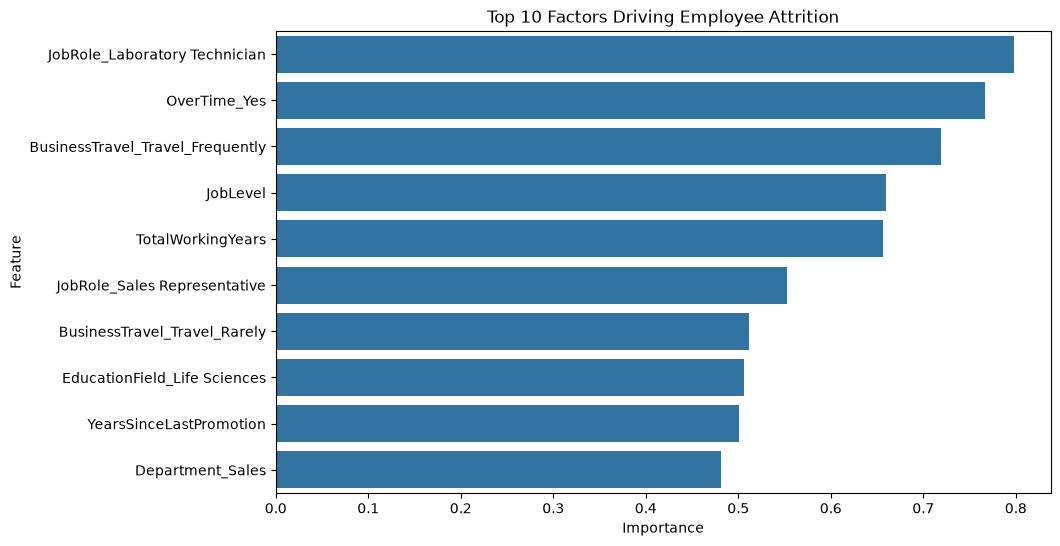

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Factors Driving Employee Attrition")

plt.savefig("charts/feature_importance.png")
plt.show()

The analysis revealed that factors such as overtime, job role, monthly income, years at the company, and work-life balance strongly influence employee attrition. Employees working overtime and those with lower work-life balance scores were more likely to leave. Salary alone did not fully explain attrition, as job satisfaction and career growth factors also played significant roles. HR teams should prioritize retention efforts for departments and job roles showing the highest attrition rates. Regular career discussions, improved work-life balance initiatives, and targeted retention programs for high-risk employees could help reduce attrition. One limitation of this model is that it relies only on historical HR data and cannot capture personal reasons or external factors influencing employee decisions.